In [30]:
import tskit
import msprime
import pyslim 
import demesdraw as dem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from utils import *
from relate_utils import *


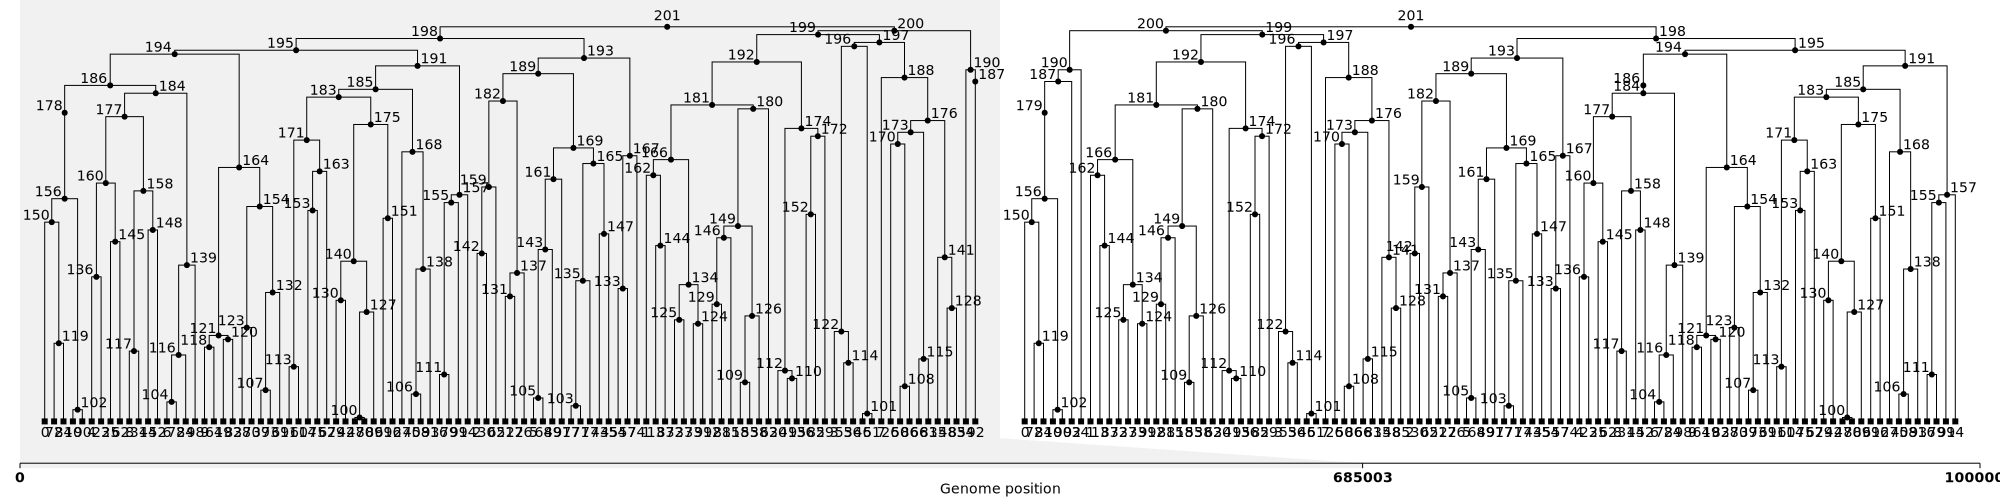

In [31]:
# Generate msprime sim
#rate_map = msprime.RateMap(
#    position=[0, 495000, 505000, 1000000],
#    rate=[0, 1e-5, 0]
#)
#seed = np.random.uniform(1,1000000,1)
seed = 986514.64772209
ts = msprime.sim_ancestry(
    50, recombination_rate=1e-7, sequence_length=1e6, random_seed=int(seed), record_full_arg=True, model='smc', stop_at_local_mrca=False)
ts.draw_svg(size=(2000,500), time_scale='rank')

In [32]:
seed

986514.64772209

In [33]:
df = recombination_summary(ts)
df

,rec_number,child,descendant_samples,descendant_nodes,breakpoint,time,tree_index_left,tree_index_right,coal_left,coal_right
0,1,156,"[0, 10, 72, 84, 90]","[0, 10, 72, 84, 90, 102, 119, 150]",685003.0,0.133959,0,1,4,3


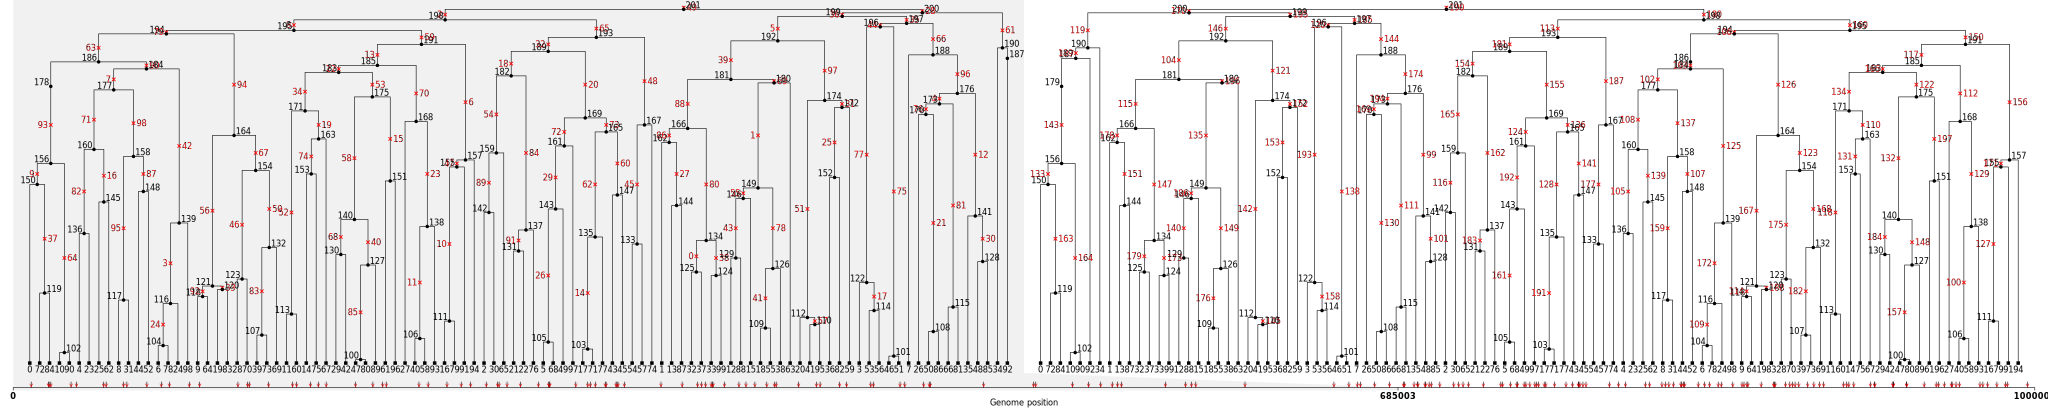

In [34]:
mts = add_mutations(ts, seed=2)
mts.draw_svg(size=(3500,700), time_scale='rank')

In [35]:
mts

In [36]:
# Run it                                                                          
incomp_matrix = compute_incompatibility_matrix(mts, recsites=find_recsites(mts))  

Computing incompatibility:   0%|          | 0/198 [00:00<?, ?it/s]

In [37]:
coal_nodes = np.where(mts.tables.nodes.flags == 0)[0]                                                                                                 
nodes = np.concatenate([mts.samples(), coal_nodes])                                                                                                   
genotypes = mts.genotype_matrix(samples=nodes, isolated_as_missing=False) 
incompatible_sites = np.where(incomp_matrix.any(axis=1))[0]                             
incomp_genotypes = genotypes[incompatible_sites, :].T  

In [38]:
coal_nodes

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192,
       193, 194, 195, 196, 197, 198, 199, 200, 201])

In [39]:
incompatible_sites

array([  2,   8,  28,  61,  63,  79, 106, 119, 160, 170, 180, 189])

In [40]:
incomp_genotypes

array([[1, 1, 0, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(200, 12), dtype=int32)

In [41]:
# Sub-matrix of incomp_matrix for only the incompatible sites
sub_incomp = incomp_matrix[np.ix_(incompatible_sites, incompatible_sites)]

# Compute all incompatible pair genotypes once
all_genos, pairs = incomp_pair_genotypes(incomp_genotypes, sub_incomp)

# Filter to pairs crossing the point
cg = cross_point_genotypes(all_genos, pairs, point=5)

cg.shape

(16, 200)

In [42]:
genotypes

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(198, 200), dtype=int32)

In [43]:
df = get_incomp_site_position(mts, incomp_matrix, df)
df

,rec_number,child,descendant_samples,descendant_nodes,breakpoint,time,tree_index_left,tree_index_right,coal_left,coal_right,incomp_split_point,incomp_site_left,incomp_site_right
0,1,156,"[0, 10, 72, 84, 90]","[0, 10, 72, 84, 90, 102, 119, 150]",685003.0,0.133959,0,1,4,3,6,79,106


## RUN relate

In [44]:

# 2. Run Relate on the full tree sequence
run_relate(
    mts,
    recombination_rate=1e-7,
    mutation_rate=1.25e-8,
    Ne=50,            # diploid — converted to haploid internally
    relate_loc='../relate',
    filename="my_sim",
    threads=1,
    memory=16,
)


Writing input files...done


In [45]:
# 3. Map all mutations to the 10kb hotspot region + 5kb on each side,
relate_ts = tskit.load('my_sim_relate.trees')
site_ids = map_mutations_to_region(relate_ts, start_pos=0, end_pos=1000000)



Building map of mutations by carrier set...


  Scanning mutations: 100%|██████████| 15/15 [00:00<00:00, 4606.76it/s]


  Found 67 unique carrier sets.
Mapping mutations to trees in [0, 1000000]...


  Mapping to region: 100%|██████████| 15/15 [00:00<00:00, 920.36it/s]

  Mapped 123 unique sites to the region.


In [46]:
relate_ts

In [15]:
# Run it                                                                          
relate_incomp_matrix = compute_incompatibility_matrix(relate_ts, recsites=find_recsites(relate_ts))  

Computing incompatibility:   0%|          | 0/196 [00:00<?, ?it/s]

In [23]:
relate_coal_nodes = np.where(relate_ts.tables.nodes.flags == 0)[0]                                                                                                 
relate_nodes = np.concatenate([relate_ts.samples(), relate_coal_nodes])                                                                                                   
relate_genotypes = relate_ts.genotype_matrix(samples=relate_nodes, isolated_as_missing=False) 
relate_incompatible_sites = np.where(relate_incomp_matrix.any(axis=1))[0]                             
relate_incomp_genotypes = genotypes[relate_incompatible_sites, :].T  

In [29]:
relate_coal_nodes

array([ 100,  101,  102, ..., 1582, 1583, 1584], shape=(1485,))

In [24]:
relate_incompatible_sites

array([  1,   2,   8,  22,  23,  28,  62,  69,  77,  78, 105, 111, 118,
       128, 159, 169, 179])

In [25]:
relate_incomp_genotypes

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(200, 17), dtype=int32)

In [26]:
# Sub-matrix of incomp_matrix for only the incompatible sites
relate_sub_incomp = relate_incomp_matrix[np.ix_(relate_incompatible_sites, relate_incompatible_sites)]

# Compute all incompatible pair genotypes once
relate_all_genos, relate_pairs = incomp_pair_genotypes(relate_incomp_genotypes, relate_sub_incomp)

# Filter to pairs crossing the point
relate_cg = cross_point_genotypes(relate_all_genos, relate_pairs, point=5)

cg.shape

(16, 200)

In [27]:
relate_genotypes

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(196, 1585), dtype=int32)